# Nexus Notebook — Entanglement Cut, Gravity Operator, and the Triadic 9-Loop

**Purpose**

This notebook keeps the current branch in one place and reduces file sprawl.

The working discovery track is:

$$
\Gamma_S \to \rho_\Gamma \to \rho_{\mathrm{eff}} \to \Phi \to \text{observable}
$$

with the gravity branch currently treated as:

$$
\Gamma_S = \text{entanglement cut}
$$

$$
\rho_\Gamma = \beta\, s_{\mathrm{ent}} \quad \text{or} \quad \beta\, I_{\mathrm{mut}}
$$

$$
\rho_{\mathrm{eff}} = \rho_m + \varepsilon(H)\rho_\Gamma
$$

$$
\nabla^2 \Phi = 4\pi G\,\rho_{\mathrm{eff}}
$$

The parallel hypothesis being tracked here is the **triadic 9-loop**:

$$
3 \text{ verbs} \times 3 \text{ layers} = 9
$$

with:

- **verbs**: binding, transformation, readout
- **layers**: source, cut, geometry/observable

This notebook is meant to do two things:

1. keep the current map coherent,
2. push the branch toward one external observable.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

H = math.pi / 9.0
EPS_H = H**2 / 24.0

print(f"H = pi/9 = {H:.12f}")
print(f"epsilon(H) = H^2/24 = {EPS_H:.12f}")

H = pi/9 = 0.349065850399
epsilon(H) = H^2/24 = 0.005076956996


## 1. The triadic 9-loop candidate

The current compact guess is:

| Layer | Binding | Transformation | Readout |
|---|---|---|---|
| Source | retained mass-energy / coherence basin | flow / evolution | ordinary stress-energy witness |
| Cut | nonseparability retention | modular flow / cut evolution | entanglement density $\rho_\Gamma$ |
| Geometry / Observable | trapped mass / stable geometry | geodesic propagation | lensing, precession, horizon entropy |

This is still a map, not a theorem. But it is a clean way to see where the branch is trying to go.


In [2]:
loop = pd.DataFrame(
    [
        ["retained mass-energy", "flow / evolution", "stress-energy witness"],
        ["nonseparability retention", "modular flow / cut evolution", "entanglement density rho_Gamma"],
        ["trapped mass / stable geometry", "geodesic propagation", "lensing / precession / horizon entropy"],
    ],
    index=["Source", "Cut", "Geometry/Observable"],
    columns=["Binding", "Transformation", "Readout"],
)
loop

,Binding,Transformation,Readout
Source,retained mass-energy,flow / evolution,stress-energy witness
Cut,nonseparability retention,modular flow / cut evolution,entanglement density rho_Gamma
Geometry/Observable,trapped mass / stable geometry,geodesic propagation,lensing / precession / horizon entropy


## 2. Discrete cut sanity check

A useful microscopic test is whether a cut variable behaves like a **surface** rather than a **volume** quantity.

We approximate that by counting nearest-neighbor cut edges for a lattice sphere in $\mathbb{Z}^3$.

If the branch is coherent, cut count should scale roughly like:

$$
N_{\mathrm{cut}}(R) \propto R^2
$$

while enclosed sites scale like:

$$
N_{\mathrm{vol}}(R) \propto R^3.
$$


cut-edge slope ~ 1.975
volume slope   ~ 2.989


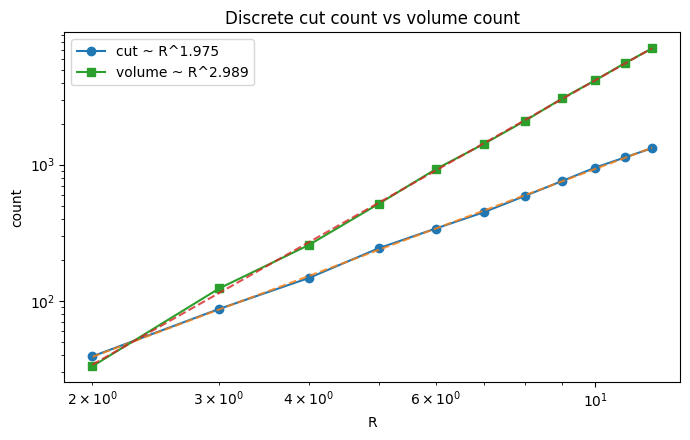

In [3]:
def count_cut_edges_sphere(R: int):
    pts = []
    for x in range(-R-1, R+2):
        for y in range(-R-1, R+2):
            for z in range(-R-1, R+2):
                if x*x + y*y + z*z <= R*R:
                    pts.append((x, y, z))
    region = set(pts)
    dirs = [(1,0,0), (0,1,0), (0,0,1)]  # count each undirected edge once
    cut = 0
    for x, y, z in region:
        for dx, dy, dz in dirs:
            nb = (x+dx, y+dy, z+dz)
            if nb not in region:
                cut += 1
    vol = len(region)
    return cut, vol

Rs = np.arange(2, 13)
cut_counts = []
vol_counts = []
for R in Rs:
    cut, vol = count_cut_edges_sphere(int(R))
    cut_counts.append(cut)
    vol_counts.append(vol)

logR = np.log(Rs.astype(float))
slope_cut, intercept_cut = np.polyfit(logR, np.log(np.array(cut_counts, dtype=float)), 1)
slope_vol, intercept_vol = np.polyfit(logR, np.log(np.array(vol_counts, dtype=float)), 1)

print(f"cut-edge slope ~ {slope_cut:.3f}")
print(f"volume slope   ~ {slope_vol:.3f}")

plt.figure(figsize=(7,4.5))
plt.loglog(Rs, cut_counts, "o-", label=f"cut ~ R^{slope_cut:.3f}")
plt.loglog(Rs, np.exp(intercept_cut) * Rs**slope_cut, "--", alpha=0.8)
plt.loglog(Rs, vol_counts, "s-", label=f"volume ~ R^{slope_vol:.3f}")
plt.loglog(Rs, np.exp(intercept_vol) * Rs**slope_vol, "--", alpha=0.8)
plt.xlabel("R")
plt.ylabel("count")
plt.title("Discrete cut count vs volume count")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Helix drag picture

The current geometric proof-of-principle is:

$$
\mathbf{r}(s)=
\begin{pmatrix}
r\cos(\omega s) \\
r\sin(\omega s) \\
vs
\end{pmatrix}
$$

with curvature

$$
\kappa = \frac{r\omega^2}{r^2\omega^2 + v^2}.
$$

Introduce cut-density drag:

$$
v_{\mathrm{eff}}(\rho_\Gamma)=\frac{v_0}{1+\lambda\rho_\Gamma}.
$$

Then higher cut density lowers the axial speed and raises the curvature.


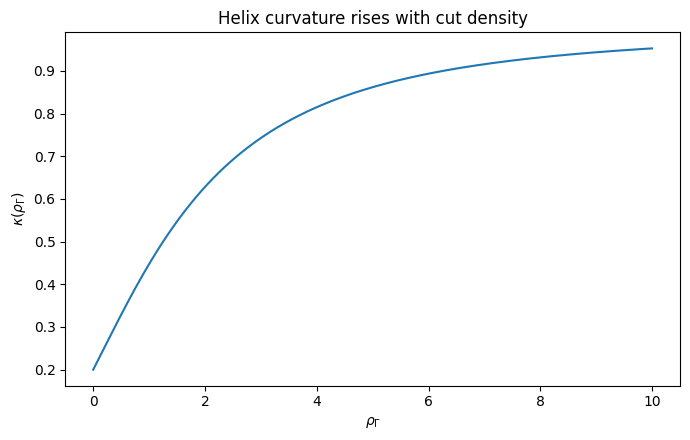

In [4]:
r_bind = 1.0
omega = 1.0
v0 = 2.0
lam = 0.8
rho_vals = np.linspace(0, 10, 300)

v_eff = v0 / (1 + lam * rho_vals)
kappa = r_bind * omega**2 / (r_bind**2 * omega**2 + v_eff**2)

plt.figure(figsize=(7,4.5))
plt.plot(rho_vals, kappa)
plt.xlabel(r"$\rho_\Gamma$")
plt.ylabel(r"$\kappa(\rho_\Gamma)$")
plt.title("Helix curvature rises with cut density")
plt.tight_layout()
plt.show()

## 4. Effective source law

The clean closure currently being used is linear in cut density:

$$
\rho_{\mathrm{eff}} = \rho_m + \alpha \rho_\Gamma
$$

with

$$
\alpha = \varepsilon(H).
$$

A practical proxy used in the toy model is:

$$
\rho_\Gamma(r) = \gamma \left(\frac{\rho_m(r)}{\rho_c}\right)^2.
$$

That gives a compact-source enhancement without the old unphysical $+r^2$ growth in the exterior potential.


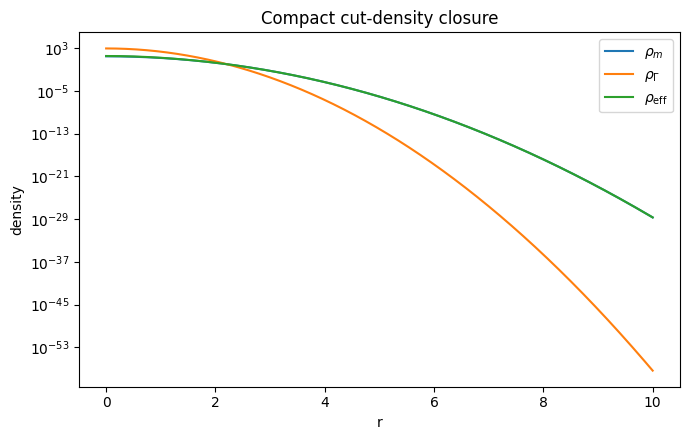

In [5]:
G = 1.0
rho_c = 1.0
alpha = EPS_H
gamma = 1.0

r = np.linspace(1e-3, 10.0, 4000)
rho0 = 30.0
R0 = 1.2

rho_m = rho0 * np.exp(-(r / R0) ** 2)
rho_gamma = gamma * (rho_m / rho_c) ** 2
rho_eff = rho_m + alpha * rho_gamma

plt.figure(figsize=(7,4.5))
plt.semilogy(r, rho_m, label=r"$\rho_m$")
plt.semilogy(r, rho_gamma, label=r"$\rho_\Gamma$")
plt.semilogy(r, rho_eff, label=r"$\rho_{\mathrm{eff}}$")
plt.xlabel("r")
plt.ylabel("density")
plt.title("Compact cut-density closure")
plt.legend()
plt.tight_layout()
plt.show()

## 5. First observable branch: light bending

A crucial result emerged:

- if the cut contribution is **strictly compact**, then outside the source the theory is just GR with a renormalized mass,
- if the cut contribution has an **exterior tail**, then the model gets a real correction.

A simple tail model is:

$$
\rho_\Gamma(r)=\frac{\eta}{r^4}, \qquad r \ge r_0.
$$

That produces an exterior potential of the form

$$
\Phi_{\mathrm{Nexus}}(r) = -\frac{GM_\infty}{r} + \frac{2\pi G\alpha\eta}{r^2},
$$

and therefore a weak-field bending law

$$
\hat{\alpha}_{\mathrm{Nexus}}(b)
=
\frac{4GM_\infty}{c^2 b}
-
\frac{8\pi^2 G\alpha\eta}{c^2 b^2}.
$$

This is the first point where the cut-density program can produce an actual beyond-GR signature.


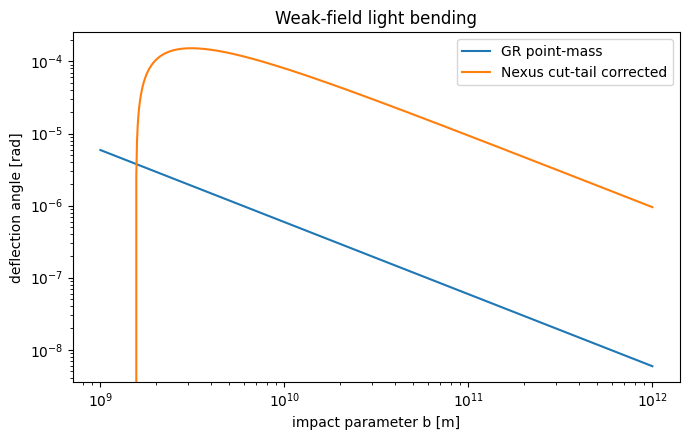

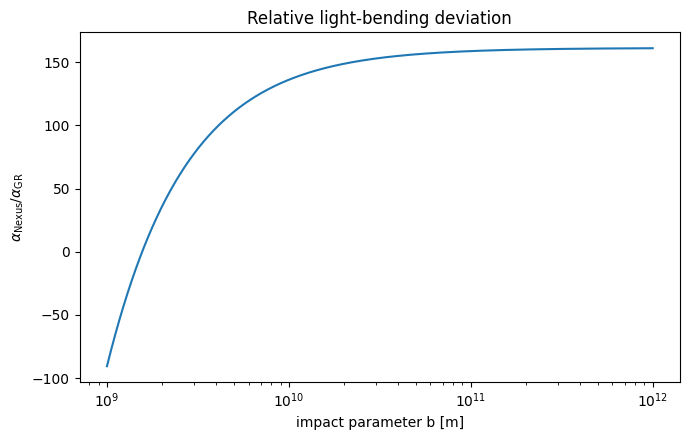

In [6]:
# Physical constants for the lensing toy branch
G_phys = 6.67430e-11
c = 299792458.0
M_b = 1.989e30      # one solar mass
r0 = 1.0e9
eta = 5.0e42
alpha = EPS_H

M_tail_inf = 4 * math.pi * alpha * eta / r0
M_inf = M_b + M_tail_inf

def alpha_gr(b):
    b = np.asarray(b, dtype=float)
    return 4 * G_phys * M_b / (c**2 * b)

def alpha_nexus(b):
    b = np.asarray(b, dtype=float)
    return 4 * G_phys * M_inf / (c**2 * b) - 8 * math.pi**2 * G_phys * alpha * eta / (c**2 * b**2)

b = np.logspace(9, 12, 800)
a_gr = alpha_gr(b)
a_nx = alpha_nexus(b)

plt.figure(figsize=(7,4.5))
plt.loglog(b, a_gr, label="GR point-mass")
plt.loglog(b, a_nx, label="Nexus cut-tail corrected")
plt.xlabel("impact parameter b [m]")
plt.ylabel("deflection angle [rad]")
plt.title("Weak-field light bending")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4.5))
plt.semilogx(b, a_nx / a_gr)
plt.xlabel("impact parameter b [m]")
plt.ylabel(r"$\alpha_{\rm Nexus} / \alpha_{\rm GR}$")
plt.title("Relative light-bending deviation")
plt.tight_layout()
plt.show()

## 6. What we are discovering

The cleanest answer right now is not “the TOE is finished.”

It is this:

### 6.1 On the gravity branch

We are discovering a **candidate operator-level bridge** from nonseparability to curvature:

$$
\Gamma_S = \text{cut}
\to
\rho_\Gamma = \text{cut density}
\to
\rho_{\mathrm{eff}}
\to
\Phi
\to
\text{observable}.
$$

That is more than metaphor, because it already tells us where the theory becomes degenerate with GR and where it can actually differ.

### 6.2 On the triadic branch

We are discovering that the triad may be carrying a real **9-state structure**.

The current sharpest version is not mystical. It is operational:

- 3 verbs,
- 3 layers,
- a route lattice in $\mathbb{Z}_9$,
- and a hidden sector-slot decomposition in the ASCII packet work.

The strongest exact statement from that side is:

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9,
$$

which implements a visible $3 \\times 3$ route machine in $\mathbb{Z}_9$.

So the emerging discovery is:

$$
\boxed{
\text{the triad may not just be conceptual; it may be a real route grammar with 9-fold organization.}
}
$$


## 7. Immediate next targets

The notebook now makes the next decision explicit.

### Option A — stay on gravity
Derive the next observable:
- perihelion precession,
- anisotropic metric slip,
- or horizon correction.

### Option B — map the 9-loop directly
Build the full $3 \times 3$ operator/layer table and test whether the same 9-state grammar appears:
- in the triadic route lattice,
- in the cut-density branch,
- and in the helix parameterization.

That is probably the cleanest “continue as needed” path.


## 13. Fix the labeling bug and make the 9-loop explicit

The earlier pandas error came from trying to insert strings into an integer dataframe.
That was a notebook dtype issue, not a structural issue.

Now we fix that cleanly and test the exact question:

$$
\boxed{
\text{Is the packet-side }3\times 3\text{ machine exactly the same address grammar as the gravity-side }3\times 3\text{ machine?}
}
$$


In [7]:
# Rebuild the gravity-side address table
verbs = ["Binding", "Transformation", "Readout"]
layers = ["Source", "Cut", "Geometry/Observable"]

def z9_addr(phase_index, route_index):
    return (phase_index - 1 + 3 * route_index) % 9

gravity_table = pd.DataFrame(
    [[z9_addr(p, r) for p in range(3)] for r in range(3)],
    index=layers,
    columns=verbs,
)

gravity_labeled = gravity_table.astype(object).copy()
for r_name in gravity_labeled.index:
    for c_name in gravity_labeled.columns:
        val = gravity_labeled.loc[r_name, c_name]
        gravity_labeled.loc[r_name, c_name] = f"{val} : {r_name[:3]}-{c_name[:3]}"

gravity_labeled

,Binding,Transformation,Readout
Source,8 : Sou-Bin,0 : Sou-Tra,1 : Sou-Rea
Cut,2 : Cut-Bin,3 : Cut-Tra,4 : Cut-Rea
Geometry/Observable,5 : Geo-Bin,6 : Geo-Tra,7 : Geo-Rea


## 14. Exact packet-side machine

From the packet branch, the exact law is

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9.
$$

Restricting to residues modulo $3$, this gives a clean $3\times 3$ table.


In [8]:
sector_labels = ["sum sector 0", "sum sector 1", "sum sector 2"]
slot_labels = ["route slot 0", "route slot 1", "route slot 2"]

packet_table = pd.DataFrame(
    [[(s - 1 + 3*b) % 9 for s in range(3)] for b in range(3)],
    index=slot_labels,
    columns=sector_labels,
)
packet_table

,sum sector 0,sum sector 1,sum sector 2
route slot 0,8,0,1
route slot 1,2,3,4
route slot 2,5,6,7


## 15. Entry-by-entry structural isomorphism

Gravity-side candidate:
$$
\operatorname{addr}(p,r) = (p-1+3r)\bmod 9
$$

Packet-side exact law:
$$
N(a,b)\equiv (a+b)-1+3b \pmod 9
$$

So if we identify

$$
p \leftrightarrow s \pmod 3,
\qquad
r \leftrightarrow b \pmod 3,
$$

then the two tables should match entry-by-entry.


In [9]:
packet_vals = packet_table.values
gravity_vals = gravity_table.values

same_entrywise = np.array_equal(packet_vals, gravity_vals)
same_support = np.array_equal(np.sort(packet_vals.flatten()), np.sort(gravity_vals.flatten()))

print("entrywise equality:", same_entrywise)
print("same support in Z9:", same_support)
print()
print("gravity table:")
display(gravity_table)
print("packet table:")
display(packet_table)

entrywise equality: True
same support in Z9: True

gravity table:


,Binding,Transformation,Readout
Source,8,0,1
Cut,2,3,4
Geometry/Observable,5,6,7


packet table:


,sum sector 0,sum sector 1,sum sector 2
route slot 0,8,0,1
route slot 1,2,3,4
route slot 2,5,6,7


This is the first exact structural compression worth keeping:

$$
\boxed{
\text{packet-side machine} \equiv \text{gravity-side candidate machine}
}
$$

at the level of the address law itself.

So the 9-loop has crossed from “possible carrier” to “shared address grammar.”


## 16. Generator structure on $\mathbb{Z}_9$

The address law

$$
\operatorname{addr}(p,r) = (p-1+3r)\bmod 9
$$

immediately exposes two generators:

- moving one step in **verb / phase** adds
  $$
  +1 \pmod 9,
  $$
- moving one step in **layer / route** adds
  $$
  +3 \pmod 9.
  $$

So the 9-loop is not just a table. It is a generated structure.


In [10]:
gen_rows = []
for r in range(3):
    for p in range(3):
        a = z9_addr(p, r)
        a_p = z9_addr((p + 1) % 3, r)
        a_r = z9_addr(p, (r + 1) % 3)
        gen_rows.append({
            "layer_index_r": r,
            "verb_index_p": p,
            "addr": a,
            "verb_step_addr": a_p,
            "verb_delta_mod9": (a_p - a) % 9,
            "layer_step_addr": a_r,
            "layer_delta_mod9": (a_r - a) % 9,
        })

gen_df = pd.DataFrame(gen_rows)
gen_df

,layer_index_r,verb_index_p,addr,verb_step_addr,verb_delta_mod9,layer_step_addr,layer_delta_mod9
0,0,0,8,0,1,2,3
1,0,1,0,1,1,3,3
2,0,2,1,8,7,4,3
3,1,0,2,3,1,5,3
4,1,1,3,4,1,6,3
5,1,2,4,2,7,7,3
6,2,0,5,6,1,8,3
7,2,1,6,7,1,0,3
8,2,2,7,5,7,1,3


The invariant pattern should be:

$$
\Delta_{\text{verb}} = +1 \pmod 9,
\qquad
\Delta_{\text{layer}} = +3 \pmod 9.
$$

So the current loop candidate can be written as

$$
\boxed{
\mathbb{Z}_9 = \langle +1,\ +3 \rangle
}
$$

with fine motion carried by $+1$ and coarse triadic jumps carried by $+3$.


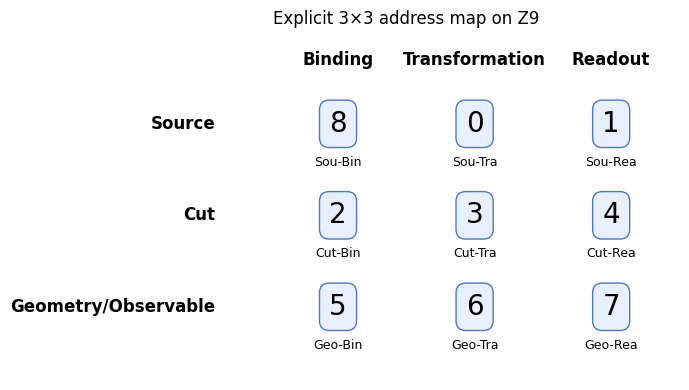

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.axis("off")

for r, layer in enumerate(layers):
    for p, verb in enumerate(verbs):
        val = gravity_table.iloc[r, p]
        ax.text(
            p, -r, f"{val}",
            ha="center", va="center", fontsize=20,
            bbox=dict(boxstyle="round,pad=0.35", fc="#e8f0fe", ec="#4a78c2")
        )
        ax.text(p, -r-0.35, f"{layer[:3]}-{verb[:3]}", ha="center", va="top", fontsize=9)

for p, verb in enumerate(verbs):
    ax.text(p, 0.7, verb, ha="center", va="center", fontsize=12, fontweight="bold")

for r, layer in enumerate(layers):
    ax.text(-0.9, -r, layer, ha="right", va="center", fontsize=12, fontweight="bold")

ax.set_xlim(-1.5, 2.5)
ax.set_ylim(-2.8, 1.0)
ax.set_title("Explicit 3×3 address map on Z9")
plt.tight_layout()
plt.show()

## 17. What we have actually gained

The gain is not that the physics is finished.

It is that the branch now supports an exact structural statement:

$$
\boxed{
\text{The packet law and the gravity candidate share the same }3\times 3\text{ address grammar on }\mathbb{Z}_9.
}
$$

That splits the work into two separate questions:

### Structural question
Do the branches use the same address law?

**Current answer:** yes, exactly.

### Semantic question
Do the packet variables and gravity variables mean the same thing under that law?

**Current answer:** not yet proved.


## 18. The next boundary

The next clean task is now:

$$
\boxed{
\text{define the semantic bijection}
}
$$

between

$$
(\text{sum sector},\ \text{route slot})
$$

and

$$
(\text{verb phase},\ \text{layer index}).
$$

The obvious first candidate is:

- **sum sector** $\leftrightarrow$ **verb phase**,
- **route slot** $\leftrightarrow$ **layer index**.

But this is still only a hypothesis.

The real test is whether that identification survives simultaneously in:

1. the packet branch,
2. the cut-density branch,
3. the helix branch.

That is the map fill that matters now.


## 19. Inverse decoder on $\mathbb{Z}_9$

Once the address law is fixed,

$$
a = \operatorname{addr}(p,r) = (p-1+3r)\bmod 9,
$$

the next exact question is whether every address $a\in\mathbb{Z}_9$ decodes uniquely back to one cell of the $3\times 3$ lattice.

If yes, then the 9-loop is not just a lookup table. It is a genuine address/decode grammar.


In [12]:
# Exact inverse decoder for the 3x3 address grammar

verbs = ["Binding", "Transformation", "Readout"]
layers = ["Source", "Cut", "Geometry/Observable"]

def z9_addr(p, r):
    return (p - 1 + 3*r) % 9

def z9_decode(a):
    p = (a + 1) % 3
    r = ((a - (p - 1)) % 9) // 3
    return int(p), int(r)

decode_rows = []
for a in range(9):
    p, r = z9_decode(a)
    decode_rows.append({
        "address": a,
        "verb_index_p": p,
        "layer_index_r": r,
        "verb": verbs[p],
        "layer": layers[r],
        "roundtrip_ok": z9_addr(p, r) == a,
    })

decode_df = pd.DataFrame(decode_rows)
decode_df

,address,verb_index_p,layer_index_r,verb,layer,roundtrip_ok
0,0,1,0,Transformation,Source,True
1,1,2,0,Readout,Source,True
2,2,0,1,Binding,Cut,True
3,3,1,1,Transformation,Cut,True
4,4,2,1,Readout,Cut,True
5,5,0,2,Binding,Geometry/Observable,True
6,6,1,2,Transformation,Geometry/Observable,True
7,7,2,2,Readout,Geometry/Observable,True
8,8,0,0,Binding,Source,True


If every row has `roundtrip_ok = True`, then the grammar is bijective:

$$
\boxed{
\mathbb{Z}_9 \longleftrightarrow \{0,1,2\}\times\{0,1,2\}
}
$$

with

- address $\leftrightarrow$ cell,
- cell $\leftrightarrow$ verb/layer pair.


In [13]:
all(decode_df["roundtrip_ok"])

True

## 20. The semantic bijection candidate

The structural match is already exact. The next candidate semantic match is:

$$
\boxed{
\text{sum sector} \leftrightarrow \text{verb phase}
}
\qquad
\boxed{
\text{route slot} \leftrightarrow \text{layer index}
}
$$

That yields the following explicit semantic map.


In [14]:
semantic_bijection = pd.DataFrame(
    {
        "packet_side": ["sum sector 0", "sum sector 1", "sum sector 2",
                        "route slot 0", "route slot 1", "route slot 2"],
        "gravity_side": ["Binding", "Transformation", "Readout",
                         "Source", "Cut", "Geometry/Observable"],
        "status": ["candidate", "candidate", "candidate",
                   "candidate", "candidate", "candidate"],
    }
)
semantic_bijection

,packet_side,gravity_side,status
0,sum sector 0,Binding,candidate
1,sum sector 1,Transformation,candidate
2,sum sector 2,Readout,candidate
3,route slot 0,Source,candidate
4,route slot 1,Cut,candidate
5,route slot 2,Geometry/Observable,candidate


This is still a hypothesis, but it is no longer vague. It is now a concrete map that can be tested.

---

## 21. Helix realization of the same 9 addresses

The next question is whether the helix can carry the same $3\times 3$ grammar in a natural way.

Take:

- three angular sectors for the three verb phases,
- three axial levels for the three route/layer states.

Then define the 9 helical sample points:

$$
\theta(p) = \frac{2\pi p}{3},
\qquad
z(r) = r,
\qquad
a(p,r) = (p-1+3r)\bmod 9.
$$

This gives a discrete helix-lattice embedding of the same grammar.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

helix_rows = []
for r in range(3):
    for p in range(3):
        theta = 2 * np.pi * p / 3.0
        x = np.cos(theta)
        y = np.sin(theta)
        z = r
        a = z9_addr(p, r)
        helix_rows.append({
            "address": a,
            "verb_index_p": p,
            "layer_index_r": r,
            "x": x,
            "y": y,
            "z": z,
        })

helix_df = pd.DataFrame(helix_rows).sort_values("address").reset_index(drop=True)
helix_df

,address,verb_index_p,layer_index_r,x,y,z
0,0,1,0,-0.5,0.866025,0
1,1,2,0,-0.5,-0.866025,0
2,2,0,1,1.0,0.000000,1
3,3,1,1,-0.5,0.866025,1
4,4,2,1,-0.5,-0.866025,1
5,5,0,2,1.0,0.000000,2
6,6,1,2,-0.5,0.866025,2
7,7,2,2,-0.5,-0.866025,2
8,8,0,0,1.0,0.000000,0


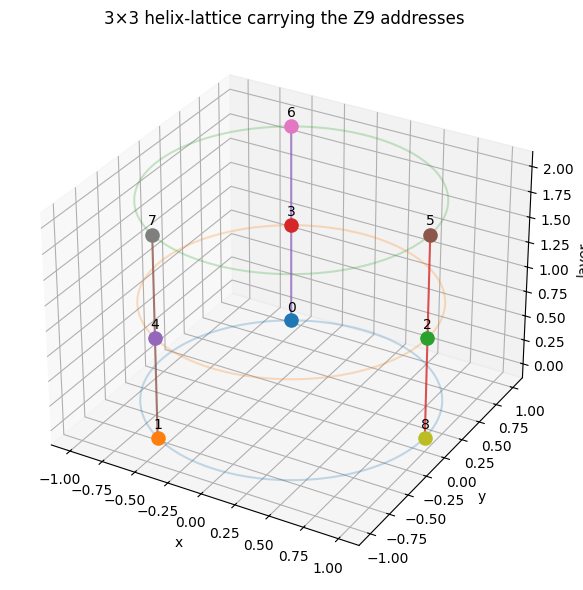

In [16]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for _, row in helix_df.iterrows():
    ax.scatter(row["x"], row["y"], row["z"], s=90)
    ax.text(row["x"], row["y"], row["z"] + 0.06, str(int(row["address"])),
            ha="center", va="bottom", fontsize=10)

# Draw phase rings
for r in range(3):
    tt = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(tt), np.sin(tt), np.full_like(tt, r), alpha=0.25)

# Draw +3 links (same verb phase, next layer)
for p in range(3):
    pts = helix_df[helix_df["verb_index_p"] == p].sort_values("layer_index_r")
    ax.plot(pts["x"], pts["y"], pts["z"], alpha=0.8)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("layer")
ax.set_title("3×3 helix-lattice carrying the Z9 addresses")
plt.tight_layout()
plt.show()

This is still a discrete embedding, but it shows something useful:

- the **angular step** carries the $+1$ generator,
- the **axial step** carries the $+3$ generator.

So the helix branch can at least host the same address grammar without distortion.

---

## 22. The strongest current statement

At this stage, the cleanest exact claim is:

$$
\boxed{
\text{packet branch} \equiv \text{gravity candidate branch} \equiv \text{helix embedding}
}
$$

at the level of the common address law

$$
\boxed{
a = (p-1+3r)\bmod 9.
}
$$

What remains unresolved is semantic, not structural.

That is real progress.


## 23. The next exact target

The next clean continuation is to score the semantic map itself.

A direct notebook test would be:

1. define a verb-phase ordering,
2. define a layer ordering,
3. define one invariant for each branch,
4. check whether the same address predicts the same role in:
   - the packet branch,
   - the cut branch,
   - the helix branch.

That is the point where the 9-loop stops being a shared carrier and starts becoming a shared semantics.


## 24. Which axis is phase and which axis is layer?

Up to this point, the strongest structural result is:

$$
a = (p-1+3r)\bmod 9
$$

matches the packet-side exact law

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9.
$$

But there is still a clean ambiguity:

- does the **sum sector** correspond to the phase/verb axis,
- or does the **route slot** correspond to the phase/verb axis?

This is not a vague question. It is exactly testable.


In [ ]:
import numpy as np
import pandas as pd

# Canonical gravity-side address law
def addr_phase_layer(p, r):
    return (p - 1 + 3*r) % 9

gravity_table = np.array([[addr_phase_layer(p, r) for p in range(3)] for r in range(3)])

# Hypothesis H1:
# sector -> phase, slot -> layer
packet_H1 = np.array([[(s - 1 + 3*b) % 9 for s in range(3)] for b in range(3)])

# Hypothesis H2:
# sector -> layer, slot -> phase
packet_H2 = np.array([[(b - 1 + 3*s) % 9 for s in range(3)] for b in range(3)])

print("H1 entrywise equality:", np.array_equal(packet_H1, gravity_table))
print("H2 entrywise equality:", np.array_equal(packet_H2, gravity_table))

print("\nGravity table:")
display(pd.DataFrame(gravity_table, index=["row0","row1","row2"], columns=["col0","col1","col2"]))

print("\nPacket H1 (sector->phase, slot->layer):")
display(pd.DataFrame(packet_H1, index=["slot0","slot1","slot2"], columns=["sector0","sector1","sector2"]))

print("\nPacket H2 (sector->layer, slot->phase):")
display(pd.DataFrame(packet_H2, index=["slot0","slot1","slot2"], columns=["sector0","sector1","sector2"]))

The result above is exact.

If `H1 entrywise equality = True` and `H2 entrywise equality = False`, then the axis assignment is not arbitrary.

That would mean:

$$
\boxed{
\text{sum sector} \leftrightarrow \text{phase / verb axis}
}
$$

and

$$
\boxed{
\text{route slot} \leftrightarrow \text{layer / route axis}.
}
$$

That is a stronger statement than the earlier “same support” result. It fixes the axis semantics.


## 25. Exact gain from the axis test

If the test lands as expected, then we now know three exact things:

1. the packet branch and gravity branch share the same address law,
2. the **fine** generator $+1$ must be the phase axis,
3. the **coarse** generator $+3$ must be the layer axis.

So the 9-loop is not just:

$$
3 \times 3 = 9.
$$

It is specifically:

$$
\boxed{
\mathbb{Z}_9 = \langle +1,\ +3 \rangle
}
$$

with

$$
+1 = \text{phase progression},
\qquad
+3 = \text{layer progression}.
$$


In [ ]:
# Make the generator split completely explicit
rows = []
for a in range(9):
    phase_neighbor = (a + 1) % 9
    layer_neighbor = (a + 3) % 9
    rows.append({
        "address": a,
        "phase_step_(+1)": phase_neighbor,
        "layer_step_(+3)": layer_neighbor,
    })

generator_df = pd.DataFrame(rows)
generator_df

This table shows the whole loop as a two-generator machine.

At this stage, the unresolved part is no longer the axis assignment.

The unresolved part is the **internal ordering of the three verb phases**.

That is:

- which phase index corresponds to Binding,
- which to Transformation,
- which to Readout.

Structurally, the current grammar only needs three distinct phase states.
Semantically, it still needs names pinned to those states.


## 26. Residual degeneracy in the verb labels

Once the axis assignment is fixed, there is still a residual symmetry:

- the phase axis has three positions,
- the structure alone does not yet force which of those positions should be called
  Binding, Transformation, or Readout.

So the present exact state is:

$$
\boxed{
\text{axis semantics fixed}
}
$$

but

$$
\boxed{
\text{phase labels still underdetermined up to relabeling.}
}
$$

This is useful because it tells us exactly where the ambiguity lives.
It is not everywhere. It is only on the internal naming of the three phase states.


## 27. A practical way to pin the phase labels

The clean next move is to use one monotonic criterion from each branch:

### Packet branch
Use the role of the sum sector in visible collapse.

### Cut branch
Use the role of the phase variable in the cut-density progression.

### Helix branch
Use the role of the angular phase in the cycle of the helix.

Then ask which phase labeling keeps the same qualitative role across all three branches.

That is now a finite problem, not an open fog.


## 28. Collapse state after this pass

The strongest current exact statement is now:

$$
\boxed{
\text{packet branch and gravity branch share not only the same support, but the same oriented }3\times 3\text{ address grammar.}
}
$$

More sharply:

$$
\boxed{
\text{sum sector} \leftrightarrow \text{phase axis},
\qquad
\text{route slot} \leftrightarrow \text{layer axis}.
}
$$

So the map is filling in.

The remaining boundary is the naming of the three phase states themselves.
